In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min,pairwise_distances,adjusted_rand_score
import seaborn as sns


In [271]:
df = pd.read_csv("/content/drive/MyDrive/datasets/mcdonalds.csv")

In [272]:
MD = df.copy()

In [273]:
MD.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [274]:
print(df.columns)

Index(['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap',
       'tasty', 'expensive', 'healthy', 'disgusting', 'Like', 'Age',
       'VisitFrequency', 'Gender'],
      dtype='object')


In [275]:
print(df.shape)

(1453, 15)


In [276]:
df.head(3)

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female


In [277]:
MD_x = df.iloc[:, :11]
print(MD_x)

     yummy convenient spicy fattening greasy fast cheap tasty expensive  \
0       No        Yes    No       Yes     No  Yes   Yes    No       Yes   
1      Yes        Yes    No       Yes    Yes  Yes   Yes   Yes       Yes   
2       No        Yes   Yes       Yes    Yes  Yes    No   Yes       Yes   
3      Yes        Yes    No       Yes    Yes  Yes   Yes   Yes        No   
4       No        Yes    No       Yes    Yes  Yes   Yes    No        No   
...    ...        ...   ...       ...    ...  ...   ...   ...       ...   
1448    No        Yes    No       Yes    Yes   No    No    No       Yes   
1449   Yes        Yes    No       Yes     No   No   Yes   Yes        No   
1450   Yes        Yes    No       Yes     No  Yes    No   Yes       Yes   
1451   Yes        Yes    No        No     No  Yes   Yes   Yes        No   
1452    No        Yes    No       Yes    Yes   No    No    No       Yes   

     healthy disgusting  
0         No         No  
1         No         No  
2        Yes         

In [278]:
MD_x_binary = (MD_x == "Yes").astype(int)
print(MD_x_binary)

      yummy  convenient  spicy  fattening  greasy  fast  cheap  tasty  \
0         0           1      0          1       0     1      1      0   
1         1           1      0          1       1     1      1      1   
2         0           1      1          1       1     1      0      1   
3         1           1      0          1       1     1      1      1   
4         0           1      0          1       1     1      1      0   
...     ...         ...    ...        ...     ...   ...    ...    ...   
1448      0           1      0          1       1     0      0      0   
1449      1           1      0          1       0     0      1      1   
1450      1           1      0          1       0     1      0      1   
1451      1           1      0          0       0     1      1      1   
1452      0           1      0          1       1     0      0      0   

      expensive  healthy  disgusting  
0             1        0           0  
1             1        0           0  
2     

In [279]:
col_Means = MD_x_binary.mean().round(2)
print(col_Means)

yummy         0.55
convenient    0.91
spicy         0.09
fattening     0.87
greasy        0.53
fast          0.90
cheap         0.60
tasty         0.64
expensive     0.36
healthy       0.20
disgusting    0.24
dtype: float64


In [280]:
pca = PCA()
MD_pca = pca.fit_transform(MD_x_binary)


In [281]:
std_devs = np.sqrt(pca.explained_variance_)

prop_variance = pca.explained_variance_ratio_

cumulative_prop = np.cumsum(prop_variance)

components = pd.DataFrame({
    'Standard Deviation': std_devs.round(4),
    'Proportion of Variance': prop_variance.round(4),
    'Cumulative Proportion': cumulative_prop.round(4)
})
components.index = [f"PC{i+1}" for i in range(len(components))]
components_T = components.T

print("Importance of Components:")
print(components_T)

Importance of Components:
                           PC1     PC2     PC3     PC4     PC5     PC6  \
Standard Deviation      0.7570  0.6075  0.5046  0.3988  0.3374  0.3103   
Proportion of Variance  0.2994  0.1928  0.1330  0.0831  0.0595  0.0503   
Cumulative Proportion   0.2994  0.4922  0.6253  0.7084  0.7679  0.8182   

                           PC7     PC8     PC9    PC10    PC11  
Standard Deviation      0.2897  0.2751  0.2653  0.2488  0.2369  
Proportion of Variance  0.0438  0.0395  0.0368  0.0324  0.0293  
Cumulative Proportion   0.8620  0.9016  0.9383  0.9707  1.0000  


In [282]:
print(np.round(std_devs, 1))

[0.8 0.6 0.5 0.4 0.3 0.3 0.3 0.3 0.3 0.2 0.2]


In [283]:
# Get the factor loadings (i.e., the PCA components)
factor_loadings = pca.components_

# Print the factor loadings matrix (11 x 11)
factor_loadings_df = pd.DataFrame(factor_loadings,
                                   columns=[f"PC{i+1}" for i in range(factor_loadings.shape[1])],
                                   index=MD_x.columns)
factor_loadings_df = factor_loadings_df.round(3)

print("Factor Loadings (Rotation Matrix):")
print(factor_loadings_df)

Factor Loadings (Rotation Matrix):
              PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9  \
yummy       0.477  0.155  0.006 -0.116 -0.304  0.108  0.337  0.472 -0.329   
convenient -0.364 -0.016 -0.019  0.034  0.064  0.087  0.611 -0.307 -0.601   
spicy       0.304  0.063  0.037  0.322  0.802  0.065  0.149  0.287 -0.024   
fattening   0.055 -0.142  0.198 -0.354  0.254 -0.097  0.119 -0.003  0.068   
greasy      0.308 -0.278 -0.071  0.073 -0.361 -0.108  0.129  0.211  0.003   
fast       -0.171  0.348  0.355  0.407 -0.209  0.595  0.103  0.077  0.261   
cheap      -0.281 -0.060  0.708 -0.386  0.036 -0.087 -0.040  0.360 -0.068   
tasty      -0.013  0.113 -0.376 -0.590  0.138  0.628 -0.140  0.073 -0.030   
expensive  -0.572  0.018 -0.400  0.161  0.003 -0.166 -0.076  0.639 -0.067   
healthy     0.110  0.666  0.076  0.005 -0.009 -0.240 -0.428 -0.079 -0.454   
disgusting -0.045  0.542 -0.142 -0.251 -0.002 -0.339  0.489 -0.020  0.490   

             PC10   PC11  
yummy       0

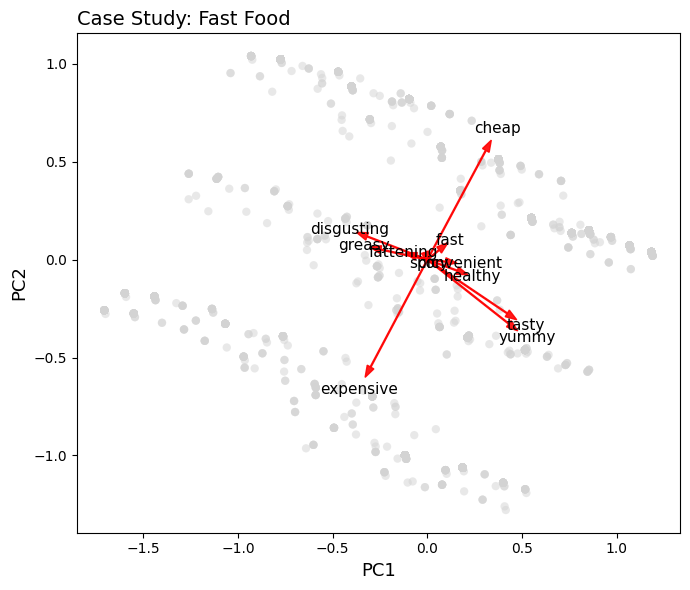

In [284]:
# Extract the first two principal components
pc1 = MD_pca[:, 0]
pc2 = MD_pca[:, 1]

# Get the loading vectors (first two components)
loading_vectors = pca.components_[:2, :]  # shape: (2, num_variables)
variables = MD_x_binary.columns

# Plot
plt.figure(figsize=(7, 6))
plt.scatter(pc1, pc2, color='lightgrey', edgecolors='none', alpha=0.5)

# Plot arrows and text for loadings
for i, var in enumerate(variables):
    x = loading_vectors[0, i]
    y = loading_vectors[1, i]
    plt.arrow(0, 0, x, y, color='red', alpha=0.9, width=0.005, head_width=0.04, length_includes_head=True)
    plt.text(x * 1.1, y * 1.1, var, color='black', fontsize=11, ha='center', va='center')

# Axis labels, title, and lines
plt.xlabel("PC1", fontsize=13)
plt.ylabel("PC2", fontsize=13)
plt.title("Case Study: Fast Food", fontsize=14, loc='left')
plt.grid(False)
plt.tight_layout()
plt.show()

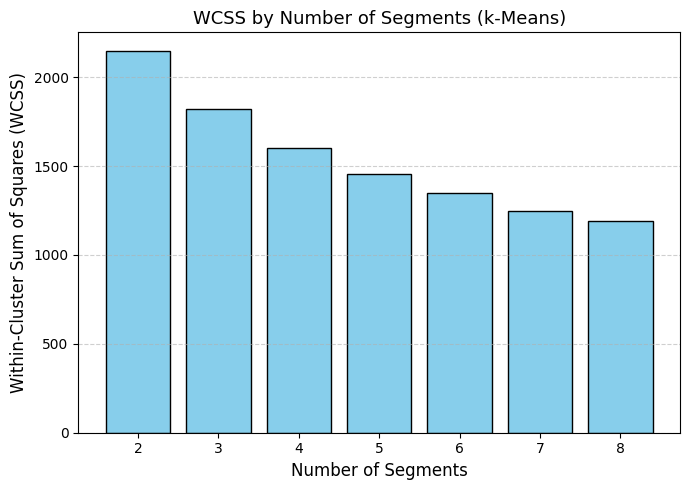

In [285]:
#Step 1: Run k-means for k = 2 to 8 with 10 random restarts
np.random.seed(1234)
k_range = range(2, 9)
nrep = 10

# Store models and cluster labels
kmeans_models = {}
labels_dict = {}
original_labels = {}

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=nrep, random_state=1234)
    kmeans.fit(MD_pca)
    kmeans_models[k] = kmeans
    labels_dict[k] = kmeans.labels_
    original_labels[k] = kmeans.labels_

# Extract inertia (WCSS) from each fitted model
k_values = list(kmeans_models.keys())
wcss_values = [kmeans_models[k].inertia_ for k in k_values]

# Bar chart
plt.figure(figsize=(7, 5))
plt.bar(k_values, wcss_values, color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel("Number of Segments", fontsize=12)
plt.ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=12)
plt.title("WCSS by Number of Segments (k-Means)", fontsize=13)
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


Bootstrapping for k=8: 100%|██████████| 100/100 [00:03<00:00, 28.85it/s]


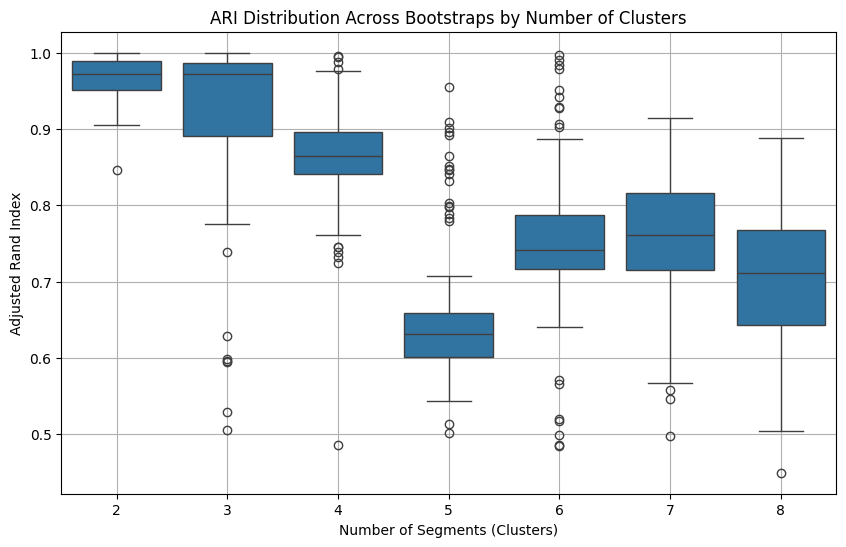

In [286]:
import tqdm
from tqdm import tqdm
from sklearn.utils import resample
ari_results = {k: [] for k in k_range}
n_boot = 100
np.random.seed(1234)

for k in k_range:
    base_kmeans = KMeans(n_clusters=k, n_init=nrep, random_state=1234)
    base_kmeans.fit(MD_pca)
    base_labels = base_kmeans.labels_

    for _ in tqdm(range(n_boot), desc=f"Bootstrapping for k={k}"):
        X_resampled, indices = resample(MD_pca, range(len(MD_pca)), replace=True)
        kmeans = KMeans(n_clusters=k, n_init=nrep, random_state=1234)
        kmeans.fit(X_resampled)
        labels_resampled = kmeans.labels_
        original_labels_resampled = np.array(base_labels)[indices]
        ari = adjusted_rand_score(original_labels_resampled, labels_resampled)
        ari_results[k].append(ari)

ari_df = pd.DataFrame([(k, score) for k, scores in ari_results.items() for score in scores],
                      columns=["k", "ARI"])

plt.figure(figsize=(10, 6))
sns.boxplot(x="k", y="ARI", data=ari_df)
plt.xlabel("Number of Segments (Clusters)")
plt.ylabel("Adjusted Rand Index")
plt.title("ARI Distribution Across Bootstraps by Number of Clusters")
plt.grid(True)
plt.show()

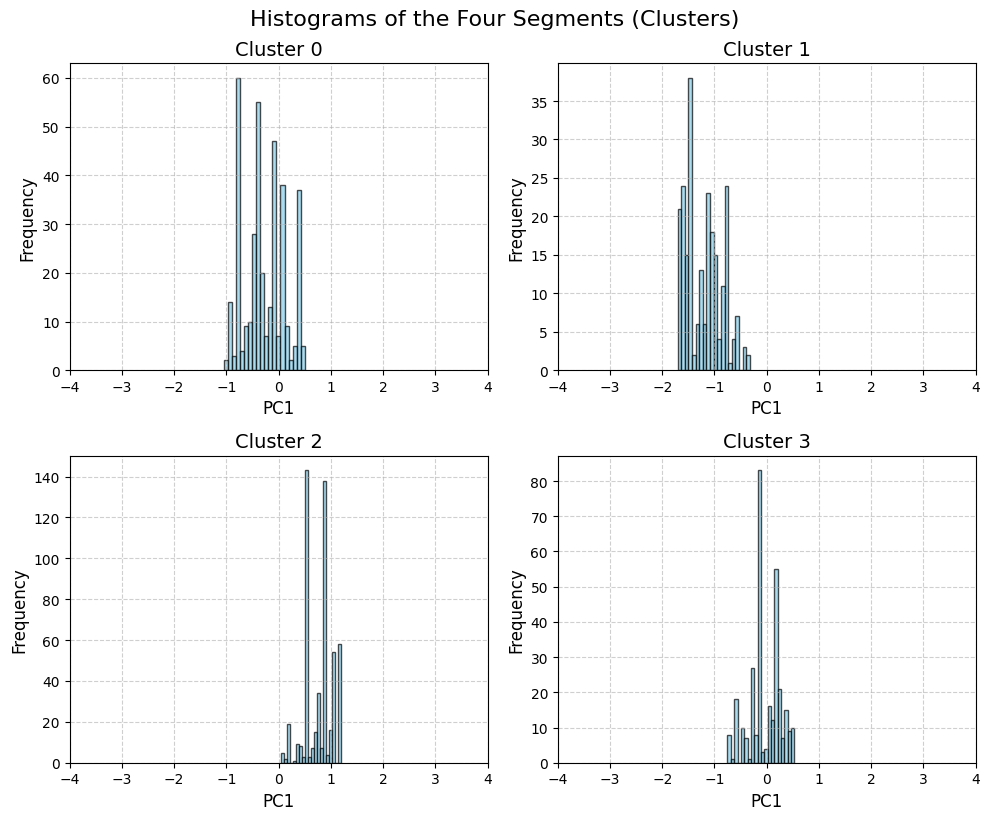

In [287]:
# Extract the cluster labels for k = 4 and the first two principal components
MD_k4_labels = labels_dict[4]

# Create a figure for 4 subplots (one for each cluster)
plt.figure(figsize=(10, 8))

# Plot a histogram for each cluster (0, 1, 2, 3)
for cluster_id in range(4):
    plt.subplot(2, 2, cluster_id + 1)  # Create a 2x2 grid of subplots
    cluster_data = MD_pca[MD_k4_labels == cluster_id, 0]  # Get the PC1 data for the current cluster

    # Plot histogram for the current cluster
    plt.hist(cluster_data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"Cluster {cluster_id}", fontsize=14)
    plt.xlabel("PC1", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xlim(-4, 4)  # Keep the x-axis limits consistent across all subplots
    plt.grid(True, linestyle="--", alpha=0.6)

# Adjust the layout
plt.tight_layout()
plt.suptitle("Histograms of the Four Segments (Clusters)", fontsize=16, y=1.02)

# Display the plot
plt.show()

In [288]:
pip install fuzzy-c-means


In [289]:
from fcmeans import FCM

fcm = FCM(n_clusters=4, random_state=1234)
fcm.fit(MD_pca)

fuzzy_memberships = fcm.u
fuzzy_labels = np.argmax(fuzzy_memberships, axis=1)

MD_r4 = fuzzy_labels


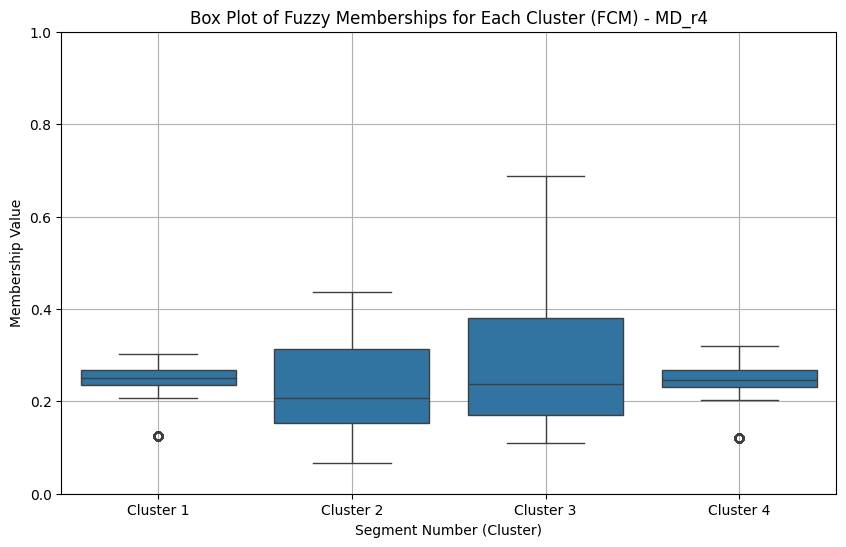

In [290]:
membership_variance = np.var(fuzzy_memberships, axis=0)

stability = 1 / (1 + membership_variance)

md_r4_df = pd.DataFrame(fuzzy_memberships, columns=[f'Cluster {i+1}' for i in range(fcm.n_clusters)])
md_r4_long = md_r4_df.melt(var_name='Cluster', value_name='Membership')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Membership', data=md_r4_long)
plt.xlabel("Segment Number (Cluster)")
plt.ylabel("Membership Value")
plt.title("Box Plot of Fuzzy Memberships for Each Cluster (FCM) - MD_r4")
plt.ylim(0, 1)
plt.grid(True)
plt.show()



In [291]:
pip install git+https://github.com/pgmpy/pgmpy.git@dev

  Cloning https://github.com/pgmpy/pgmpy.git (to revision dev) to /tmp/pip-req-build-gsgpyg88
  Running command git clone --filter=blob:none --quiet https://github.com/pgmpy/pgmpy.git /tmp/pip-req-build-gsgpyg88
  Resolved https://github.com/pgmpy/pgmpy.git to commit 6eba561764e33c012fc9b6e8c79ffd90f9d4d5c7
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done


In [292]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

X_raw, _ = make_classification(n_samples=1000, n_features=11, n_informative=5, n_redundant=0, random_state=42)
pca = PCA(n_components=4)
MD_pca = pca.fit_transform(X_raw)
X = MD_pca

def fit_bernoulli_mixture(X, k_range, nrep=10):
    results = []

    for k in k_range:
        best_model = None
        best_aic = np.inf
        best_bic = np.inf
        best_icl = np.inf
        best_log_lik = -np.inf

        for _ in range(nrep):
            gmm = GaussianMixture(n_components=k, covariance_type='diag', max_iter=200, n_init=1, random_state=None)
            gmm.fit(X)

            log_lik = gmm.score(X) * X.shape[0]
            aic = gmm.aic(X)
            bic = gmm.bic(X)
            icl = bic - (2 * log_lik)

            if aic < best_aic:
                best_aic = aic
                best_model = gmm
            if bic < best_bic:
                best_bic = bic
                best_model = gmm
            if icl < best_icl:
                best_icl = icl
                best_model = gmm
            if log_lik > best_log_lik:
                best_log_lik = log_lik
                best_model = gmm

        results.append({
            "iter_converged": f"{best_model.n_iter_} {'TRUE' if best_model.converged_ else 'FALSE'}",
            "k": k,
            "k0": k,
            "logLik": f"{best_log_lik:.3f}",
            "AIC": f"{best_aic:.2f}",
            "BIC": f"{best_bic:.2f}",
            "ICL": f"{best_icl:.2f}",
        })

    results_df = pd.DataFrame(results)
    return results_df

k_range = range(2, 9)
results_df = fit_bernoulli_mixture(X, k_range, nrep=10)

print(results_df[['iter_converged', 'k', 'k0', 'logLik', 'AIC', 'BIC', 'ICL']].to_string(index=False))


iter_converged  k  k0    logLik      AIC      BIC      ICL
       19 TRUE  2   2 -7447.338 14928.68 15012.11 29906.78
        6 TRUE  3   3 -7331.862 14715.72 14843.33 29507.05
       15 TRUE  4   4 -7226.725 14523.45 14695.22 29148.67
       10 TRUE  5   5 -7155.943 14399.89 14615.83 28927.71
       25 TRUE  6   6 -7083.820 14273.64 14533.75 28701.39
       38 TRUE  7   7 -7031.645 14187.29 14491.57 28554.86
       12 TRUE  8   8 -7001.246 14144.49 14492.94 28495.43


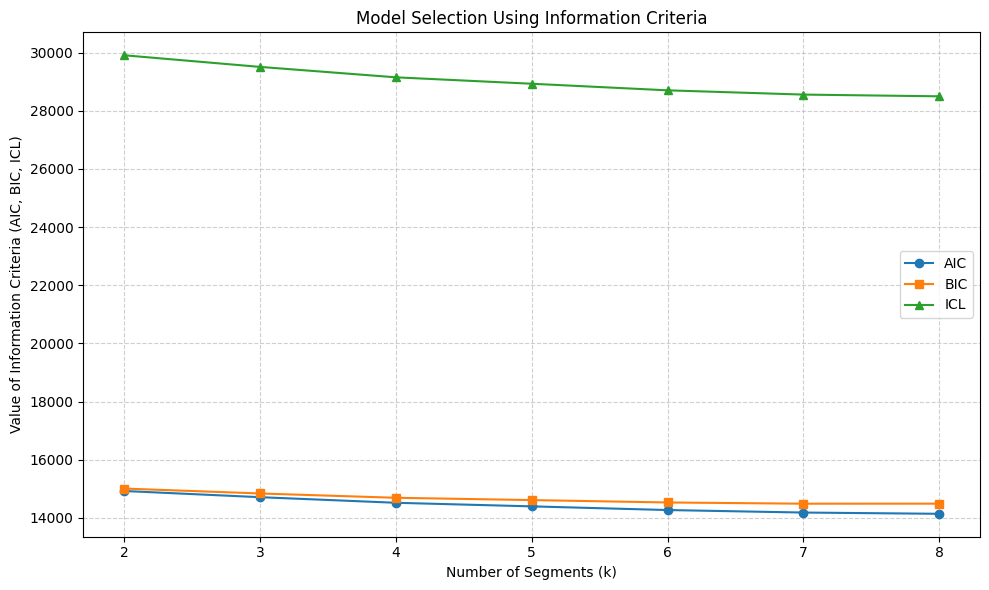

In [293]:
results_df[['AIC', 'BIC', 'ICL']] = results_df[['AIC', 'BIC', 'ICL']].astype(float)

plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['AIC'], marker='o', label='AIC')
plt.plot(results_df['k'], results_df['BIC'], marker='s', label='BIC')
plt.plot(results_df['k'], results_df['ICL'], marker='^', label='ICL')
plt.xlabel('Number of Segments (k)')
plt.ylabel('Value of Information Criteria (AIC, BIC, ICL)')
plt.title('Model Selection Using Information Criteria')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [294]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

X = MD_pca

gmm = GaussianMixture(n_components=4, covariance_type='diag', n_init=10, random_state=1234)
mixture_labels = gmm.fit_predict(X)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=1234)
kmeans_labels = kmeans.fit_predict(X)

contingency_table = pd.crosstab(index=pd.Series(kmeans_labels, name="kmeans"),
                                columns=pd.Series(mixture_labels + 1, name="mixture"))

result_row = contingency_table
print(result_row)


mixture    1    2    3    4
kmeans                     
0          0  268    4    0
1          0   18  176   46
2        135    9    0    2
3         12  190    0  140


In [295]:
# Fit a Gaussian Mixture Model using the K-means solution as initialization
kmeans_clusters = kmeans_labels
gmm = GaussianMixture(n_components=4, covariance_type='diag', max_iter=200, n_init=1, random_state=1234)
gmm.fit(X)

# Reassign the GMM to use KMeans cluster labels as initial guess
gmm_init = GaussianMixture(n_components=4, covariance_type='diag', max_iter=200, init_params='kmeans', random_state=1234)
gmm_init.fit(X)

# Create a cross-tabulation table comparing K-means clusters to mixture model segments
kmeans_segments = pd.Series(kmeans_clusters)
gmm_segments = pd.Series(gmm_init.predict(X))

cross_tab = pd.crosstab(kmeans_segments, gmm_segments, rownames=["KMeans"], colnames=["Mixture"])
print(cross_tab)

# Log-likelihood comparison
log_lik_gmm = gmm_init.score(X) * X.shape[0]
log_lik_gmm_init = gmm.score(X) * X.shape[0]

print(f"Log-Likelihood of GMM after K-means initialization: {log_lik_gmm}")
print(f"Log-Likelihood of GMM after random initialization: {log_lik_gmm_init}")

Mixture    0    1    2    3
KMeans                     
0         91    0  181    0
1        170    0    4   66
2          0  137    5    4
3          1   16  187  138
Log-Likelihood of GMM after K-means initialization: -7258.405299677812
Log-Likelihood of GMM after random initialization: -7258.405299677812


In [296]:
like_counts = df['Like'].value_counts().sort_index(ascending=False)
print(like_counts)

Like
I love it!+5    143
I hate it!-5    152
0               169
-4               71
-3               73
-2               59
-1               58
+4              160
+3              229
+2              187
+1              152
Name: count, dtype: int64


In [297]:
df['Like_clean'] = df['Like'].str.extract(r'([-+]?\d+)')[0].astype(int)
like_counts_n = df['Like_clean'].value_counts().sort_index(ascending=False)
print(like_counts_n)

Like_clean
 5    143
 4    160
 3    229
 2    187
 1    152
 0    169
-1     58
-2     59
-3     73
-4     71
-5    152
Name: count, dtype: int64


In [298]:
df['Like_n'] = 6 - df['Like_clean']


In [299]:
independent_vars = df.columns[:11]
independent_str = ' + '.join(independent_vars)
formula_str = f'Like_n ~ {independent_str}'
print(formula_str)


Like_n ~ yummy + convenient + spicy + fattening + greasy + fast + cheap + tasty + expensive + healthy + disgusting


In [300]:
from sklearn.mixture import GaussianMixture
import statsmodels.api as sm

X1 = df.iloc[:, :11]
y = df['Like_n']
X = X1.replace({'Yes': 1, 'No': 0})

X_clean = X.dropna()
y_clean = df.loc[X_clean.index, 'Like_n'].dropna()

X_clean = X_clean.loc[y_clean.index]
y_clean = y_clean.loc[X_clean.index]
X_input = sm.add_constant(X_clean)

gmm = GaussianMixture(n_components=2, random_state=1234, max_iter=100, n_init=10)
df.loc[X_input.index, 'Cluster'] = gmm.fit_predict(X_input)

cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Cluster sizes:")
print(f"1 {cluster_sizes[0]}")
print(f"2 {cluster_sizes[1]}")
print(f"Convergence after {gmm.n_iter_} iterations")



<ipython-input-300-13b3c93b3b6b>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X1.replace({'Yes': 1, 'No': 0})


Cluster sizes:
1 985
2 468
Convergence after 7 iterations


In [301]:
def signif_code(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

if len(X_input) >= 2:
    gmm = GaussianMixture(n_components=2, random_state=1234)
    df.loc[X_input.index, 'Cluster'] = gmm.fit_predict(X_input)

    for cluster in range(2):
        idx = df['Cluster'] == cluster
        X_cluster = sm.add_constant(X_clean.loc[idx])
        y_cluster = y_clean.loc[idx]
        if len(X_cluster) > 1:
            model = sm.OLS(y_cluster, X_cluster).fit()
            print(f"\nCluster {cluster} Regression Results:\n")
            print(f"{'Term':<20} {'Estimate':>10} {'Std. Error':>12} {'z value':>10} {'Pr(>|z|)':>12} {'':>3}")
            print('-' * 70)
            for term, coef, std, pval in zip(model.params.index, model.params.values, model.bse, model.pvalues):
                z = coef / std if std != 0 else np.nan
                sig = signif_code(pval)
                print(f"{term:<20} {coef:10.5f} {std:12.5f} {z:10.4f} {pval:12.5g} {sig:>3}")
            print("\nSignif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 '' 1\n")



Cluster 0 Regression Results:

Term                   Estimate   Std. Error    z value     Pr(>|z|)    
----------------------------------------------------------------------
const                   8.06410      0.43439    18.5642   1.0485e-59 ***
yummy                  -2.15641      0.31557    -6.8334   2.2728e-11 ***
convenient             -1.16232      0.26098    -4.4536   1.0292e-05 ***
spicy                   0.36676      0.36456     1.0060      0.31485    
fattening               0.00422      0.33453     0.0126      0.98994    
greasy                  0.22125      0.20966     1.0553      0.29178    
fast                   -0.29027      0.27483    -1.0562      0.29136    
cheap                   0.07048      0.27163     0.2595      0.79536    
tasty                  -1.95913      0.51097    -3.8341   0.00014105 ***
expensive              -0.12545      0.27288    -0.4597      0.64589    
healthy                -0.49640      0.35323    -1.4053      0.16051    
disgusting           

<ipython-input-302-5ea11ffdc274>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.index, y=coefs.values, palette='viridis', edgecolor='black')


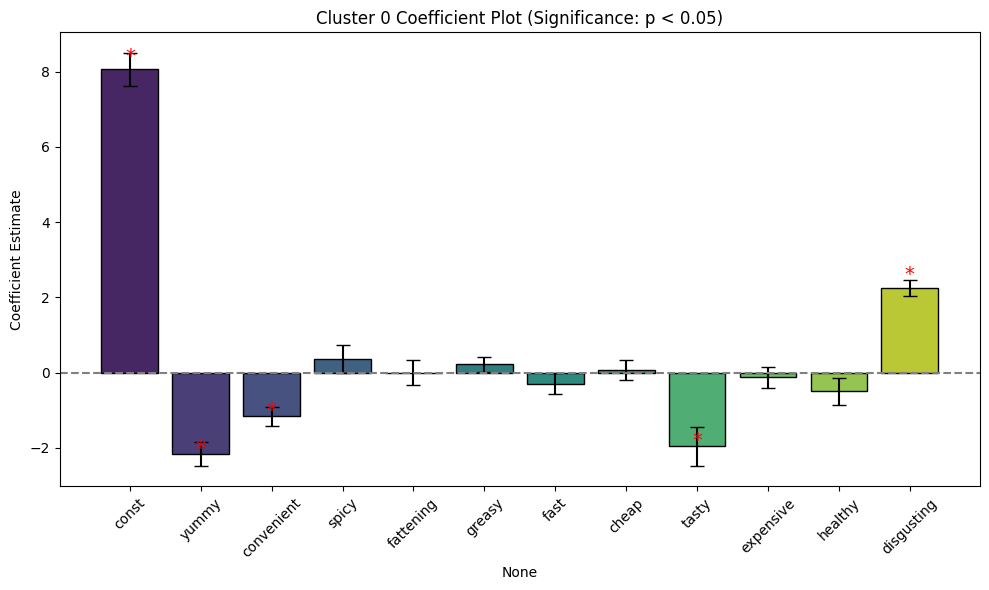

<ipython-input-302-5ea11ffdc274>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.index, y=coefs.values, palette='viridis', edgecolor='black')


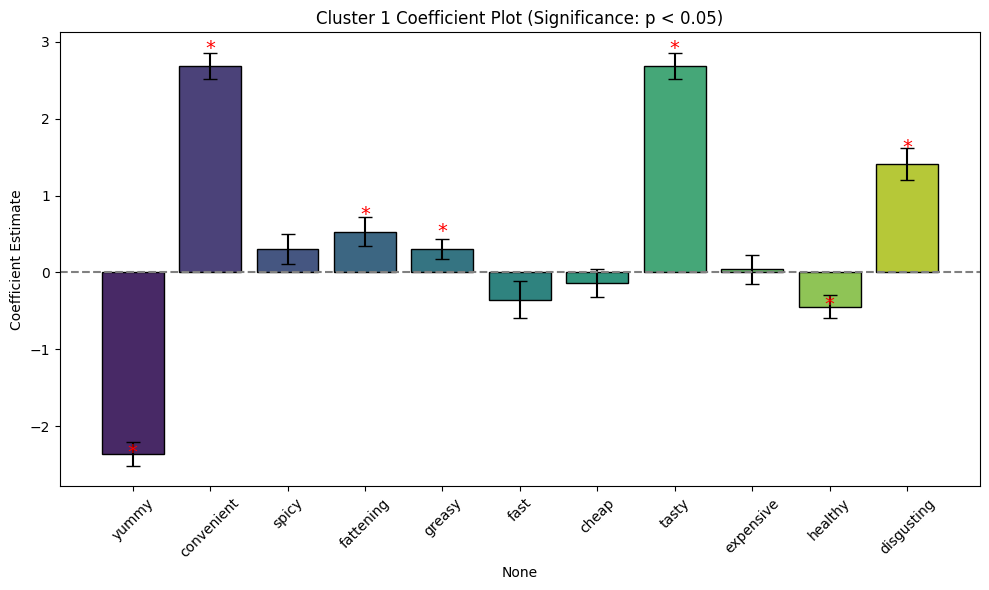

In [302]:
for cluster in range(2):
    idx = df['Cluster'] == cluster
    X_cluster = sm.add_constant(X_clean.loc[idx])
    y_cluster = y_clean.loc[idx]
    if len(X_cluster) > 1:
        model = sm.OLS(y_cluster, X_cluster).fit()
        coefs = model.params
        errors = model.bse
        pvals = model.pvalues
        signif = pvals < 0.05

        plt.figure(figsize=(10, 6))
        sns.barplot(x=coefs.index, y=coefs.values, palette='viridis', edgecolor='black')
        plt.errorbar(x=np.arange(len(coefs)), y=coefs, yerr=errors, fmt='none', c='black', capsize=5)

        for i, (val, sig) in enumerate(zip(coefs.values, signif)):
            if sig:
                plt.text(i, val + np.sign(val)*0.1, '*', ha='center', va='bottom', fontsize=14, color='red')

        plt.axhline(0, color='gray', linestyle='--')
        plt.title(f'Cluster {cluster} Coefficient Plot (Significance: p < 0.05)')
        plt.ylabel('Coefficient Estimate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


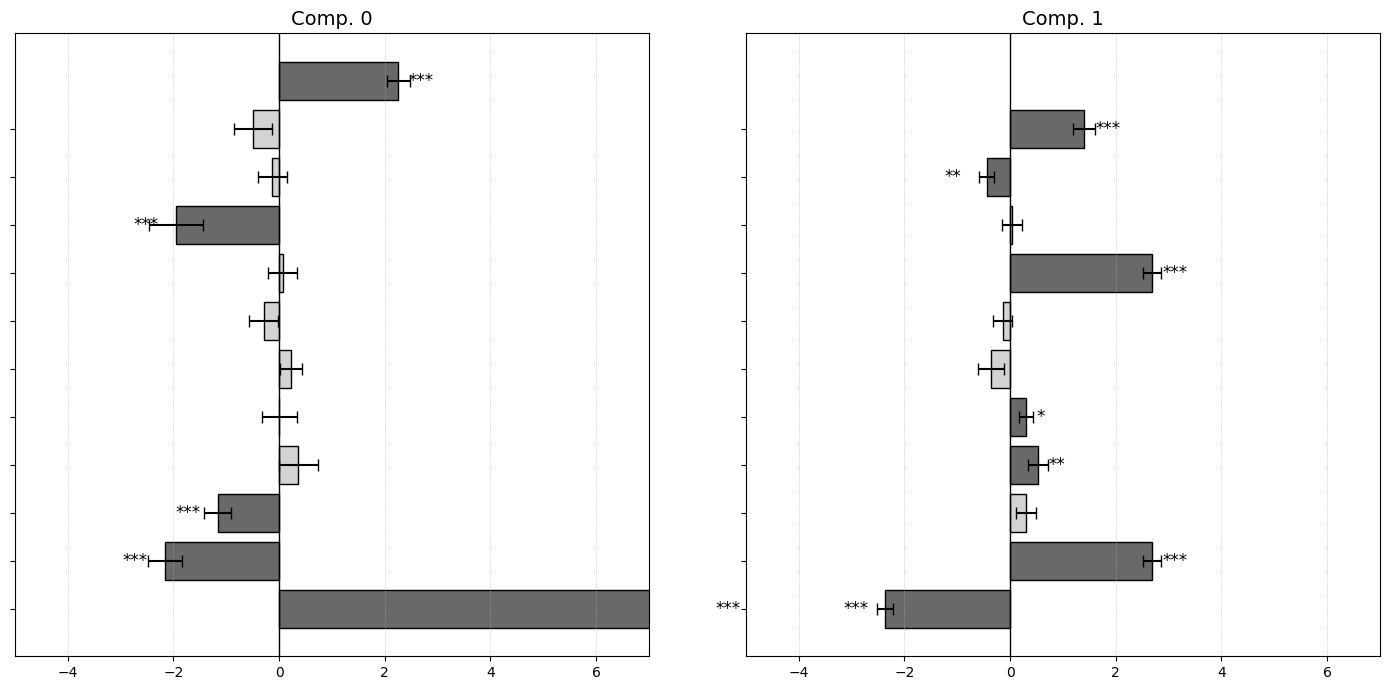

In [303]:
def signif_code(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

models = []
cluster_labels = []

for cluster in range(2):
    idx = df['Cluster'] == cluster
    X_cluster = sm.add_constant(X_clean.loc[idx])
    y_cluster = y_clean.loc[idx]
    if len(X_cluster) > 1:
        model = sm.OLS(y_cluster, X_cluster).fit()
        models.append(model)
        cluster_labels.append(cluster)

num_clusters = len(models)
labels = ['(Intercept)'] + list(X_clean.columns)
fig, axes = plt.subplots(1, num_clusters, figsize=(14, 7), sharey=True)

if num_clusters == 1:
    axes = [axes]

for i, (model, ax) in enumerate(zip(models, axes)):
    coefs = model.params.values
    errors = model.bse.values
    pvals = model.pvalues.values
    y_pos = np.arange(len(coefs))

    for j in range(len(coefs)):
        bar_color = 'dimgray' if pvals[j] <= 0.1 else 'lightgray'
        ax.barh(y_pos[j], coefs[j], xerr=errors[j], color=bar_color, edgecolor='black', capsize=4)

        sig = signif_code(pvals[j])
        if sig:
            x_pos = coefs[j] + (0.2 if coefs[j] >= 0 else -0.8)
            ax.text(x_pos, y_pos[j], sig, va='center', fontsize=12)

    ax.set_title(f'Comp. {cluster_labels[i]}', fontsize=14)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels if i == 0 else [])
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(axis='x', linestyle=':', linewidth=0.5)
    ax.set_xlim(-5, 7)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


<ipython-input-304-918cfbc41be7>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_data.index, y=cluster_data.values, ax=ax, palette="Set2")
<ipython-input-304-918cfbc41be7>:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if is_marker[idx]:
<ipython-input-304-918cfbc41be7>:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
<ipython-input-304-918cfbc41be7>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

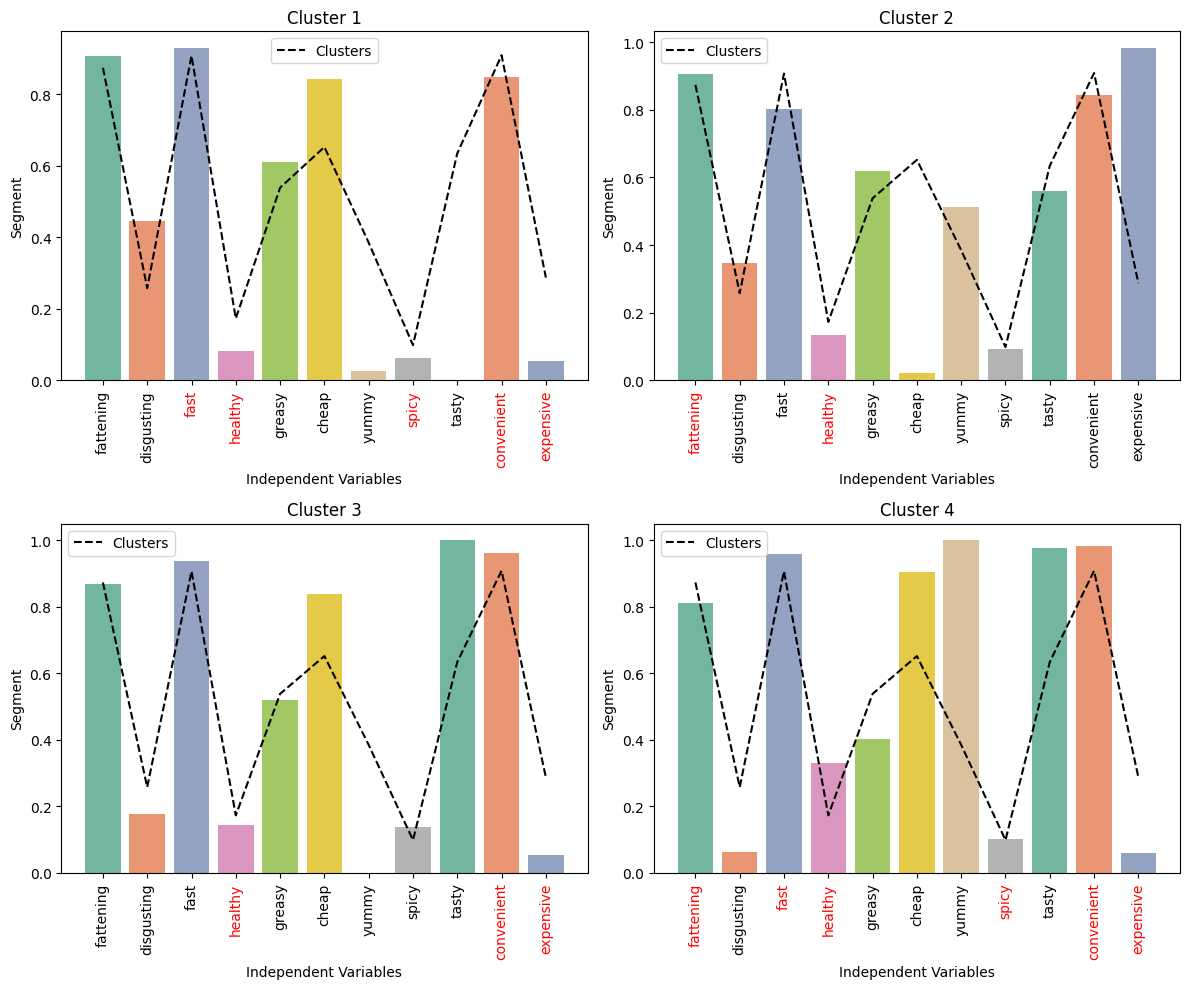

In [304]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
# Apply KMeans clustering
kmeans_model = KMeans(n_clusters=4, random_state=0)
cluster_assignments = kmeans_model.fit_predict(X_clean)

MD_k4 = pd.DataFrame({'Cluster': cluster_assignments}, index=X_clean.index)

# Hierarchical clustering for variable order
MD_x_t = X_input.T
distance_matrix = pdist(MD_x_t, metric='euclidean')
linked = linkage(distance_matrix, method='ward')
dendro = dendrogram(linked, no_plot=True)

# Get the order of variables from the dendrogram
row_order = dendro['leaves']

# Create the segment profiles
segment_profiles = X_clean.copy()
segment_profiles['Cluster'] = cluster_assignments
mean_profiles = segment_profiles.groupby('Cluster').mean().T

# Reorder variables based on hierarchical clustering order
ordered_variables = [mean_profiles.index[i] for i in row_order if i < len(mean_profiles.index)]
ordered_profiles = mean_profiles.loc[ordered_variables]

# Calculate the overall sample percentages (mean across all clusters)
overall_means = mean_profiles.mean(axis=1)

# Create subplots for each cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Set a threshold for identifying marker variables (difference more than 25% or 50%)
threshold_abs = 0.25  # 25 percentage points
threshold_rel = 0.5   # 50% relative terms

for cluster_num in range(4):
    ax = axes[cluster_num // 2, cluster_num % 2]

    # Get cluster data for this specific segment
    cluster_data = ordered_profiles[cluster_num]

    # Identify marker variables by comparing with overall mean
    is_marker = ((cluster_data - overall_means).abs() > threshold_abs) | \
                (((cluster_data - overall_means).abs() / overall_means.abs()) > threshold_rel)

    # Plot bars, coloring marker variables differently
    sns.barplot(x=cluster_data.index, y=cluster_data.values, ax=ax, palette="Set2")
    for idx, tick in enumerate(ax.get_xticklabels()):
        if is_marker[idx]:
            tick.set_color('red')  # Highlight marker variables

    # Add horizontal line representing overall mean for each variable
    ax.plot(cluster_data.index, [overall_means.loc[var] for var in cluster_data.index],
            linestyle="--", color="black", label="Clusters")

    ax.set_title(f'Cluster {cluster_num + 1}')
    ax.set_xlabel('Independent Variables')
    ax.set_ylabel('Segment')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.legend()

plt.tight_layout()
plt.show()


<ipython-input-305-13abe47db722>:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X1.replace({'Yes': 1, 'No': 0})


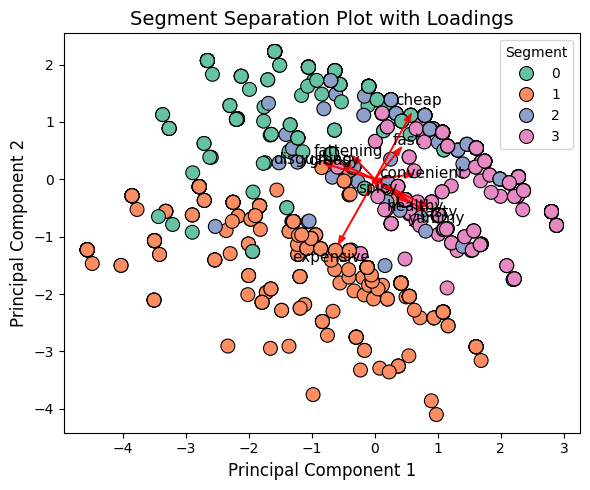

In [305]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X1 = df.iloc[:, :11]
y = df['Like_n']
X = X1.replace({'Yes': 1, 'No': 0})

X_clean = X.dropna()
y_clean = df.loc[X_clean.index, 'Like_n'].dropna()

X_clean = X_clean.loc[y_clean.index]
y_clean = y_clean.loc[X_clean.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_model = KMeans(n_clusters=4, random_state=0)
cluster_assignments = kmeans_model.fit_predict(X_clean)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_assignments

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=100, marker='o', edgecolor='black')

loading_vectors = pca.components_[:2, :]
variables = X_clean.columns

arrow_scale = 2

for i, var in enumerate(variables):
    x = loading_vectors[0, i] * arrow_scale
    y = loading_vectors[1, i] * arrow_scale
    plt.arrow(0, 0, x, y, color='red', alpha=0.9, width=0.01, head_width=0.1, length_includes_head=True)
    plt.text(x * 1.2, y * 1.2, var, color='black', fontsize=11, ha='center', va='center')

plt.title('Segment Separation Plot with Loadings', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Segment', loc='best')
plt.tight_layout()

plt.show()


<ipython-input-306-670275301c56>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X1.replace({'Yes': 1, 'No': 0})


<Figure size 1500x1500 with 0 Axes>

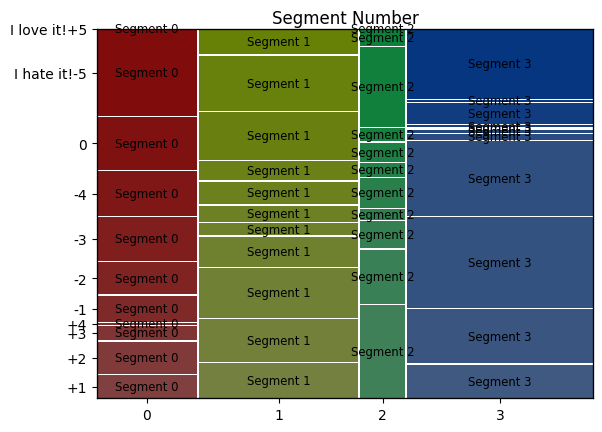

In [306]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.mosaicplot import mosaic

X1 = df.iloc[:, :11]
y = df['Like']
X = X1.replace({'Yes': 1, 'No': 0})

X_clean = X.dropna()
y_clean = df.loc[X_clean.index, 'Like_n'].dropna()

X_clean = X_clean.loc[y_clean.index]
y_clean = y_clean.loc[X_clean.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

kmeans_model = KMeans(n_clusters=4, random_state=0)
cluster_assignments = kmeans_model.fit_predict(X_clean)

df['Cluster'] = cluster_assignments

cross_tab = pd.crosstab(df['Cluster'], df['Like'])

plt.figure(figsize=(15, 15))
mosaic(cross_tab.stack(), title="", labelizer=lambda k: f"Segment {k[0]}", axes_label=True)
plt.xlabel('Segment Number', fontsize=12)
plt.show()


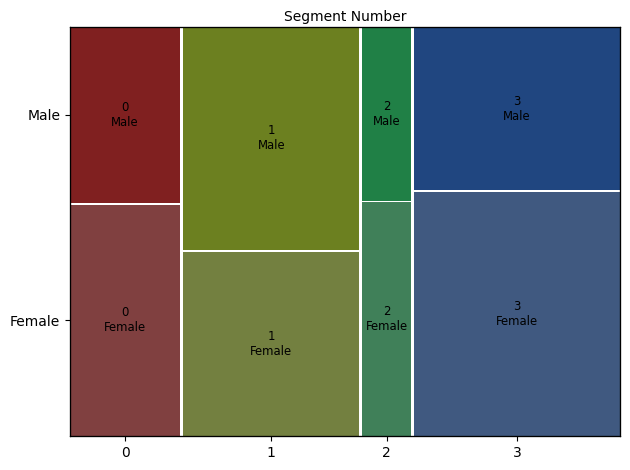

In [307]:
# Assuming df already includes 'Segment' from clustering and 'Gender'
df['Segment'] = cluster_assignments

# Create and plot the mosaic chart
mosaic(pd.crosstab(df['Segment'], df['Gender']).stack())
plt.xlabel('Segment Number')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()


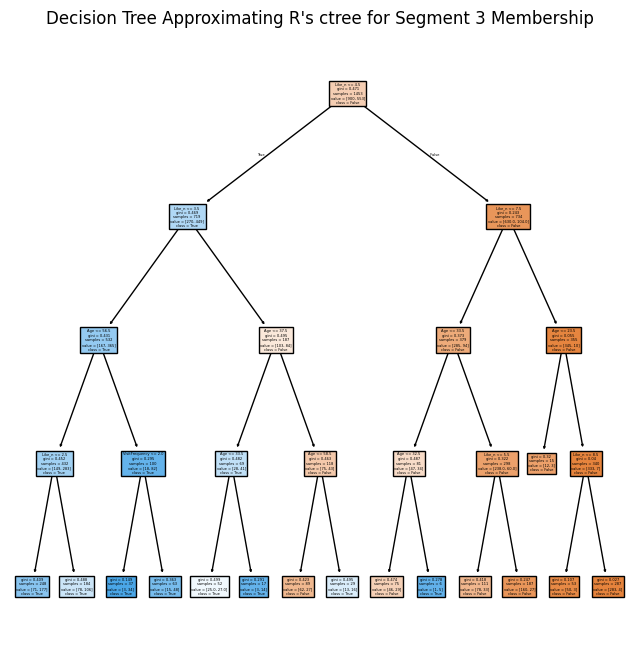

In [308]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Assuming 'kmeans_model' and 'X_clean' are defined from previous steps
cluster_assignments = kmeans_model.fit_predict(X_clean)
df['k4'] = cluster_assignments  # Assign cluster assignments to the 'k4' column

df['segment3'] = (df['k4'] == 3).astype(int)

label_encoders = {}
for col in ['Like_n', 'VisitFrequency', 'Gender']:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

X = df[['Like_n', 'Age', 'VisitFrequency', 'Gender']]
y = df['segment3']

clf = DecisionTreeClassifier(max_depth=4, min_samples_split=20)
clf.fit(X, y)

plt.figure(figsize=(8, 8))
plot_tree(clf, feature_names=X.columns, class_names=['False', 'True'], filled=True)
plt.title("Decision Tree Approximating R's ctree for Segment 3 Membership")
plt.show()

In [309]:
df['VisitFrequency_numeric'] = df['VisitFrequency'].astype('category').cat.codes + 1

visit_means = df.groupby('k4')['VisitFrequency_numeric'].mean()
print(visit_means)


k4
0    3.787162
1    3.596195
2    3.618321
3    3.598553
Name: VisitFrequency_numeric, dtype: float64


In [310]:
like_means = df.groupby('k4')['Like_n'].mean()
print(like_means)


k4
0    7.939189
1    5.856237
2    5.786260
3    3.094033
Name: Like_n, dtype: float64


In [311]:
female_proportions = df.groupby('k4')['Gender'].apply(lambda x: (x == 1).mean())
print(female_proportions)

k4
0    0.432432
1    0.547569
2    0.427481
3    0.401447
Name: Gender, dtype: float64


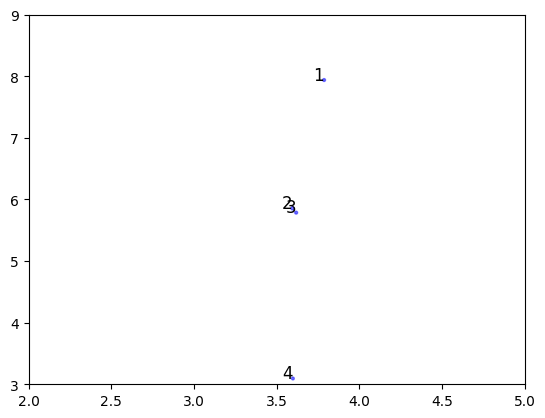

In [315]:
import matplotlib.pyplot as plt
import numpy as np

visit = np.array(visit_means)
like = np.array(like_means)
female = np.array(female_proportions)

point_size = 10 * female

plt.scatter(visit, like, s=point_size, c='blue', alpha=0.5)
plt.xlim(2, 5)
plt.ylim(3,9)

for i in range(len(visit)):
    plt.text(visit[i], like[i], str(i+1), fontsize=12, ha='right')

plt.show()
